<a href="https://colab.research.google.com/github/ShailenB/POC/blob/main/OLA_BusinessCase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading the dataset

In [ ]:
!wget https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/002/492/original/ola_driver_scaler.csv

--2026-04-11 06:47:41--  https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/002/492/original/ola_driver_scaler.csv
Resolving d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)... 13.225.41.45, 13.225.41.18, 13.225.41.124, ...
Connecting to d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)|13.225.41.45|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1127673 (1.1M) [text/plain]
Saving to: ‘ola_driver_scaler.csv’

ola_driver_scaler.c 100%[===================>]   1.08M  --.-KB/s    in 0.06s   

2026-04-11 06:47:41 (17.7 MB/s) - ‘ola_driver_scaler.csv’ saved [1127673/1127673]



Importing relevant libraries:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
with open('ola_driver_scaler.csv') as f:
  print(f.read())

,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,01/01/19,1,28,0,C23,2,57387,24/12/18,,1,1,2381060,2
1,02/01/19,1,28,0,C23,2,57387,24/12/18,,1,1,-665480,2
2,03/01/19,1,28,0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,11/01/20,2,31,0,C7,2,67016,11/06/20,,2,2,0,1
4,12/01/20,2,31,0,C7,2,67016,11/06/20,,2,2,0,1
5,12/01/19,4,43,0,C13,2,65603,12/07/19,,2,2,0,1
6,01/01/20,4,43,0,C13,2,65603,12/07/19,,2,2,0,1
7,02/01/20,4,43,0,C13,2,65603,12/07/19,,2,2,0,1
8,03/01/20,4,43,0,C13,2,65603,12/07/19,,2,2,350000,1
9,04/01/20,4,43,0,C13,2,65603,12/07/19,27/04/20,2,2,0,1
10,01/01/19,5,29,0,C9,0,46368,01/09/19,,1,1,0,1
11,02/01/19,5,29,0,C9,0,46368,01/09/19,,1,1,120360,1
12,03/01/19,5,29,0,C9,0,46368,01/09/19,03/07/19,1,1,0,1
13,08/01/20,6,31,1,C11,1,78728,31/07/20,,3,3,0,1
14,09/01/20,6,31,1,C11,1,78728,31/07/20,,3,3,0,1
15,10/01/20,6,31,1,C11,1,78728,31/07/20,,3,3,0,2
16,11/01/20,6,31,1,C11,1,78728,31/

- Creating the pandas dataframe df
- Observing first few rows of the dataset

In [ ]:
df = pd.read_csv("ola_driver_scaler.csv")
df.tail(12)

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
19092,19092,02/01/19,2787,28.0,1.0,C20,2,69498,21/07/18,NaN,1,1,250000,2
19093,19093,03/01/19,2787,28.0,1.0,C20,2,69498,21/07/18,NaN,1,1,319740,2
19094,19094,04/01/19,2787,28.0,1.0,C20,2,69498,21/07/18,NaN,1,1,0,1
19095,19095,05/01/19,2787,28.0,1.0,C20,2,69498,21/07/18,NaN,1,1,0,1
19096,19096,06/01/19,2787,28.0,1.0,C20,2,69498,21/07/18,20/06/19,1,1,0,1
19097,19097,06/01/20,2788,29.0,0.0,C27,2,70254,06/08/20,NaN,2,2,0,1
19098,19098,07/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,497690,3
19099,19099,08/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,740280,3
19100,19100,09/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,448370,3
19101,19101,10/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,0,2


Shape of the dataset

In [ ]:
df.shape

(19104, 14)

In [ ]:
print(f'Number of rows :{df.shape[0]} and columns :{df.shape[1]}' )

Number of rows :19104 and columns :14


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            19104 non-null  int64  
 1   MMM-YY                19104 non-null  object 
 2   Driver_ID             19104 non-null  int64  
 3   Age                   19043 non-null  float64
 4   Gender                19052 non-null  float64
 5   City                  19104 non-null  object 
 6   Education_Level       19104 non-null  int64  
 7   Income                19104 non-null  int64  
 8   Dateofjoining         19104 non-null  object 
 9   LastWorkingDate       1616 non-null   object 
 10  Joining Designation   19104 non-null  int64  
 11  Grade                 19104 non-null  int64  
 12  Total Business Value  19104 non-null  int64  
 13  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 2.0+ MB


In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
MMM-YY,0
Driver_ID,0
Age,61
Gender,52
City,0
Education_Level,0
Income,0
Dateofjoining,0
LastWorkingDate,17488


In [ ]:
for i in df.columns:
  if df[i].isna().sum()!=0:
    print(f"Percentage of missing values in {i} is {round(df[i].isna().sum()/df.shape[0]*100,2)}%.")
  else:
    print(f"No missing values in {i}.")

No missing values in Unnamed: 0.
No missing values in MMM-YY.
No missing values in Driver_ID.
Percentage of missing values in Age is 0.32%.
Percentage of missing values in Gender is 0.27%.
No missing values in City.
No missing values in Education_Level.
No missing values in Income.
No missing values in Dateofjoining.
Percentage of missing values in LastWorkingDate is 91.54%.
No missing values in Joining Designation.
No missing values in Grade.
No missing values in Total Business Value.
No missing values in Quarterly Rating.


Details of dataset:
- columns MMM-YY, City, Dateofjoining, LastWorkingDate are object datatypes, others are numerical
- There are some columns with missing values

Duplicate rows: Nill

In [ ]:
df.duplicated().sum()

np.int64(0)

Statistics of dtatset:

In [ ]:
df.describe(include='object').T

,count,unique,top,freq
MMM-YY,19104,24,01/01/19,1022
City,19104,29,C20,1008
Dateofjoining,19104,869,23/07/15,192
LastWorkingDate,1616,493,29/07/20,70


In [ ]:
pd.DataFrame(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,19104.0,9551.500000,5.514994e+03,0.0,4775.75,9551.5,14327.25,19103.0
Driver_ID,19104.0,1415.591133,8.107053e+02,1.0,710.00,1417.0,2137.00,2788.0
Age,19043.0,34.668435,6.257912e+00,21.0,30.00,34.0,39.00,58.0
Gender,19052.0,0.418749,4.933670e-01,0.0,0.00,0.0,1.00,1.0
Education_Level,19104.0,1.021671,8.001671e-01,0.0,0.00,1.0,2.00,2.0
Income,19104.0,65652.025126,3.091452e+04,10747.0,42383.00,60087.0,83969.00,188418.0
Joining Designation,19104.0,1.690536,8.369837e-01,1.0,1.00,1.0,2.00,5.0
Grade,19104.0,2.252670,1.026512e+00,1.0,1.00,2.0,3.00,5.0
Total Business Value,19104.0,571662.074958,1.128312e+06,-6000000.0,0.00,250000.0,699700.00,33747720.0
Quarterly Rating,19104.0,2.008899,1.009832e+00,1.0,1.00,2.0,3.00,4.0


Number of unique assignments for various columns.

In [ ]:
df.nunique()

,0
Unnamed: 0,19104
MMM-YY,24
Driver_ID,2381
Age,36
Gender,2
City,29
Education_Level,3
Income,2383
Dateofjoining,869
LastWorkingDate,493


Investigating correlation among columns

In [ ]:
df.select_dtypes(include='number').corr()

,Unnamed: 0,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
Unnamed: 0,1.000000,0.999887,0.005041,0.030030,-0.016548,-0.035774,-0.034988,-0.025225,0.003920,0.017946
Driver_ID,0.999887,1.000000,0.005457,0.030349,-0.016132,-0.035767,-0.035166,-0.025712,0.003896,0.017917
Age,0.005041,0.005457,1.000000,0.040261,-0.010245,0.191112,-0.006641,0.210702,0.108835,0.171818
Gender,0.030030,0.030349,0.040261,1.000000,-0.010123,0.013229,-0.050878,0.002076,0.008909,0.008099
Education_Level,-0.016548,-0.016132,-0.010245,-0.010123,1.000000,0.115008,0.002041,-0.039552,-0.007504,0.026064
Income,-0.035774,-0.035767,0.191112,0.013229,0.115008,1.000000,0.380878,0.778383,0.234044,0.116897
Joining Designation,-0.034988,-0.035166,-0.006641,-0.050878,0.002041,0.380878,1.000000,0.559854,-0.044446,-0.237791
Grade,-0.025225,-0.025712,0.210702,0.002076,-0.039552,0.778383,0.559854,1.000000,0.220955,0.014445
Total Business Value,0.003920,0.003896,0.108835,0.008909,-0.007504,0.234044,-0.044446,0.220955,1.000000,0.471224
Quarterly Rating,0.017946,0.017917,0.171818,0.008099,0.026064,0.116897,-0.237791,0.014445,0.471224,1.000000


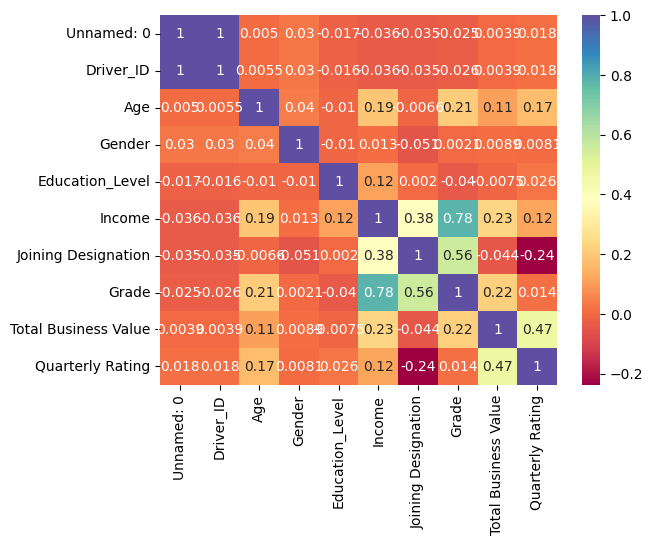

In [ ]:
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='Spectral', annot=True)
plt.show()

'Driver_ID' and 'unnamed: 0' are perfectly correlated, hence
- unnamed: 0 can be dropped without any implications on analyses.

In [ ]:
df=df.drop(['Unnamed: 0'], axis=1)

# Missing value treatment


In [ ]:
print('Column \t \t number of missing values')
for i in df.columns:
  if df[i].isna().sum()!=0:
    print(f"{i:<15}  {df[i].isna().sum():<10}" )

Column 	 	 number of missing values
Age              61        
Gender           52        
LastWorkingDate  17488     


Columns Age, and Gender have missing values, Age is imputed by column mean, and gender by the most frequent.

In [ ]:
df.Age.fillna(df.Age.mean(), inplace=True)
df.Gender.fillna(df.Gender.mode()[0], inplace=True)

In [ ]:
print('Column \t \t number of missing values')
for i in df.columns:
  if df[i].isna().sum()!=0:
    print(f"{i:<15}{df[i].isna().sum():>7}" )

Column 	 	 number of missing values
LastWorkingDate  17488


Extracting a new column DStatus which indicates if the driver is working with OLA. If DStatus is False means driver has left OLA

In [ ]:
df['DStatus']=df.LastWorkingDate.isna()

In [ ]:
df.DStatus.value_counts()

,count
DStatus,
True,17488
False,1616


DStatus on report dates.

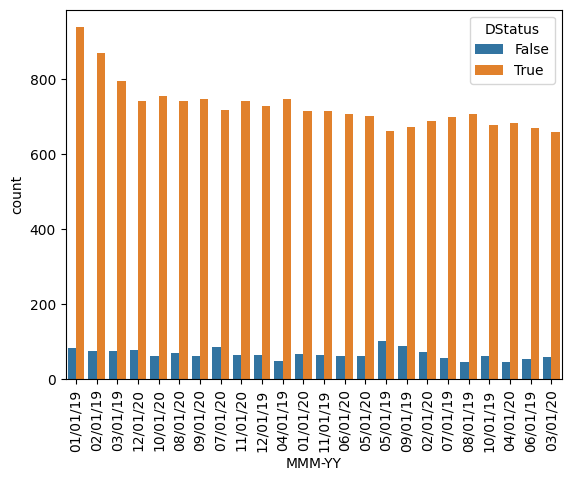

In [ ]:
sns.countplot(x='MMM-YY', data=df, hue='DStatus', order=df['MMM-YY'].value_counts().index)
plt.xticks(rotation=90)
plt.show()

# Univariate Analyses:

In [ ]:
df.nunique()

,0
MMM-YY,24
Driver_ID,2381
Age,37
Gender,2
City,29
Education_Level,3
Income,2383
Dateofjoining,869
LastWorkingDate,493
Joining Designation,5


Assigning date-time type to Dateofjoining, LastWorkingDate, and MMM-YY.

In [ ]:
df.Dateofjoining=pd.to_datetime(df.Dateofjoining)
df.LastWorkingDate=pd.to_datetime(df.LastWorkingDate)
df['MMM-YY']=pd.to_datetime(df['MMM-YY'])

# Creating new features:
- 'BV' positive, negative or zero depending upon creation of total business value

Extracting parameter 'BV', from  'Total Business Value', as '1' if 'Total Business Value' on the date of reporting is positive, '0' if 'Total Business Value' is 0, and '-1' if 'Total Business Value' is negative.

In [ ]:
df['BV']=df['Total Business Value'].apply(lambda x: 1 if x>0 else -1 if x<0 else 0)

In [ ]:
df.BV.value_counts()

,count
BV,
1,12456
0,6499
-1,149


Determining how often a driver's 'Quarterly Rating' changed in successive reporting periods.

In [ ]:
df.sort_values(by=['Driver_ID','MMM-YY'], inplace=True)
df['ratDrop']=df.groupby('Driver_ID')['Quarterly Rating'].diff()

A positive ratDrop indicate a hike in rating, and a negative one a drop.

In [ ]:
df.ratDrop.value_counts()

,count
ratDrop,
0.0,14132
-1.0,1020
1.0,943
-2.0,274
2.0,264
-3.0,52
3.0,38


In [ ]:
df.ratDrop.unique()

array([nan,  0.,  1., -3., -1., -2.,  2.,  3.])

In [ ]:
df.ratDrop.isna().sum()

2381

These nan values correspond to the first entries of Quarterly Rating for each DriverID

Imputing nan in ratDrop by 0: can neither be assigned gain or drop in rating for the first rate of a driver.

In [ ]:
df.ratDrop.fillna(0, inplace=True)

MMM-YY is date of reporting, invariably the first day of every month. The dataframe contains reporting for 24 months, 2019 to 2020.

In [ ]:
df['MMM-YY'].unique()

<DatetimeArray>
['2019-01-01 00:00:00', '2019-02-01 00:00:00', '2019-03-01 00:00:00',
 '2020-11-01 00:00:00', '2020-12-01 00:00:00', '2019-12-01 00:00:00',
 '2020-01-01 00:00:00', '2020-02-01 00:00:00', '2020-03-01 00:00:00',
 '2020-04-01 00:00:00', '2020-08-01 00:00:00', '2020-09-01 00:00:00',
 '2020-10-01 00:00:00', '2019-07-01 00:00:00', '2019-08-01 00:00:00',
 '2019-09-01 00:00:00', '2019-10-01 00:00:00', '2019-11-01 00:00:00',
 '2019-04-01 00:00:00', '2019-05-01 00:00:00', '2019-06-01 00:00:00',
 '2020-05-01 00:00:00', '2020-06-01 00:00:00', '2020-07-01 00:00:00']
Length: 24, dtype: datetime64[ns]

# Grouping dataframe by Driver_ID

There are 2,381 unique Driver_IDs, meaning the dataset represents 2,381 individual drivers. Before visualization, it's important to group the data for each driver to ensure meaningful insights.

Aggregation criterion:

'first_mode' for computing 'mode' of the series, and 'countneg' for finding number of times during the observation period, a parameter gone negative.

In [ ]:
def first_mode(series):
  return series.mode().iloc[0] if not series.mode().empty else None
def countneg(series):
  return (series<0).sum()
agg = {
    'MMM-YY': 'last',
    'Age': 'max',
    'Gender': 'first',
    'City': 'first',
    'Education_Level': 'max',
    'Income': np.mean,
    'Dateofjoining': 'first',
    'LastWorkingDate': 'last',
    'Joining Designation': 'first',
    'Grade': 'max',
    'Total Business Value': 'sum',
    'Quarterly Rating': np.mean,
    'BV': first_mode, 'ratDrop': countneg
    }

In [ ]:
df_grp=df.groupby('Driver_ID').agg(agg)

In [ ]:
df_grp.columns

Index(['MMM-YY', 'Age', 'Gender', 'City', 'Education_Level', 'Income',
       'Dateofjoining', 'LastWorkingDate', 'Joining Designation', 'Grade',
       'Total Business Value', 'Quarterly Rating', 'BV', 'ratDrop'],
      dtype='object')

In [ ]:
df_grp.shape

(2381, 14)

In [ ]:
df_grp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2381 entries, 1 to 2788
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   MMM-YY                2381 non-null   datetime64[ns]
 1   Age                   2381 non-null   float64       
 2   Gender                2381 non-null   float64       
 3   City                  2381 non-null   object        
 4   Education_Level       2381 non-null   int64         
 5   Income                2381 non-null   float64       
 6   Dateofjoining         2381 non-null   datetime64[ns]
 7   LastWorkingDate       1616 non-null   datetime64[ns]
 8   Joining Designation   2381 non-null   int64         
 9   Grade                 2381 non-null   int64         
 10  Total Business Value  2381 non-null   int64         
 11  Quarterly Rating      2381 non-null   float64       
 12  BV                    2381 non-null   int64         
 13  ratDrop               2

In [ ]:
df_grp.ratDrop.value_counts()

,count
ratDrop,
0,1485
1,560
2,241
3,76
4,19


Checking missing values in df_grp

Out of total 2381, 1616 drivers have left OLA during the period of study.

In [ ]:
df_grp.isna().sum()

,0
MMM-YY,0
Age,0
Gender,0
City,0
Education_Level,0
Income,0
Dateofjoining,0
LastWorkingDate,765
Joining Designation,0
Grade,0


Gender = 0.0 for male, and 1.0 for female

In [ ]:
df_grp.Gender.value_counts()

NameError: name 'df_grp' is not defined

# Visual Analytics:

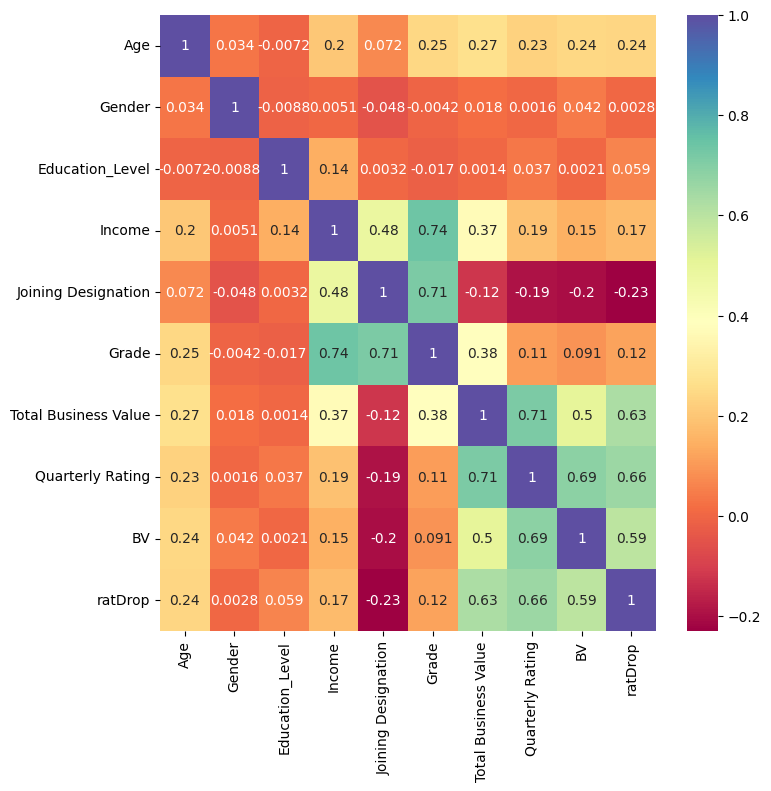

In [ ]:
plt.figure(figsize=(8,8))
sns.heatmap(df_grp.select_dtypes(include='number').corr(), annot=True, cmap='Spectral')
plt.show()

DStatus 'False' for driver left OLA, and True otherwise.

In [ ]:
df_grp['DStatus']=df_grp.LastWorkingDate.isna()

In [ ]:
df_grp.DStatus.value_counts()

,count
DStatus,
False,1616
True,765


In [ ]:
df.LastWorkingDate.dt.year.value_counts()

,count
LastWorkingDate,
2019.0,825
2020.0,786
2018.0,5


Forming age groups of drivers.

Extracting status of driver whether is working with OLA or not:

In [ ]:
df_grp['AgeGroup']=df_grp.Age.apply( lambda x: '21-25' if x > 20 and x<=25 else
                                      '26-35' if x > 25 and x<=35 else
                                      '36-45' if x > 35 and x<=45 else
                                      '46-55' if x > 45 and x<=55 else
                                      '>56')

In [ ]:
df_grp.AgeGroup.value_counts()

,count
AgeGroup,
26-35,1386
36-45,732
21-25,167
46-55,95
>56,1


In [ ]:
df_grp.DStatus.value_counts()

,count
DStatus,
False,1616
True,765


In [ ]:
df_grp['DS']=df_grp.DStatus.replace({True:'Working', False:'Left'})

In [ ]:
pd.crosstab( df_grp.DS,df_grp.AgeGroup, margins=True, margins_name='Total')

AgeGroup,21-25,26-35,36-45,46-55,>56,Total
DS,,,,,,
Left,132,961,464,58,1,1616
Working,35,425,268,37,0,765
Total,167,1386,732,95,1,2381


In [ ]:
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
fig=go.Figure()
fig.add_trace(go.Bar(x=df_grp.DS.value_counts().index, y=df_grp.DS.value_counts(), name='Driver Status'))
fig.update_layout(
    autosize=False,
    width=500,
    height=500,
    margin=dict(
        l=50,
        r=50,
        b=100,
        t=100,
        pad=20
    ),
    paper_bgcolor="LightSteelBlue",
)
fig.show()

In [ ]:
import plotly.express as px
import pandas as pd


# assume you have a "long-form" data frame
# see https://plotly.com/python/px-arguments/ for more options
df = pd.DataFrame({
    "Fruit": ["Apples", "Oranges", "Bananas", "Apples", "Oranges", "Bananas"],
    "Amount": [4, 1, 2, 2, 4, 5],
    "City": ["SF", "SF", "SF", "Montreal", "Montreal", "Montreal"]
})

px.scatter(df, x="Fruit", y='City', size="Amount")


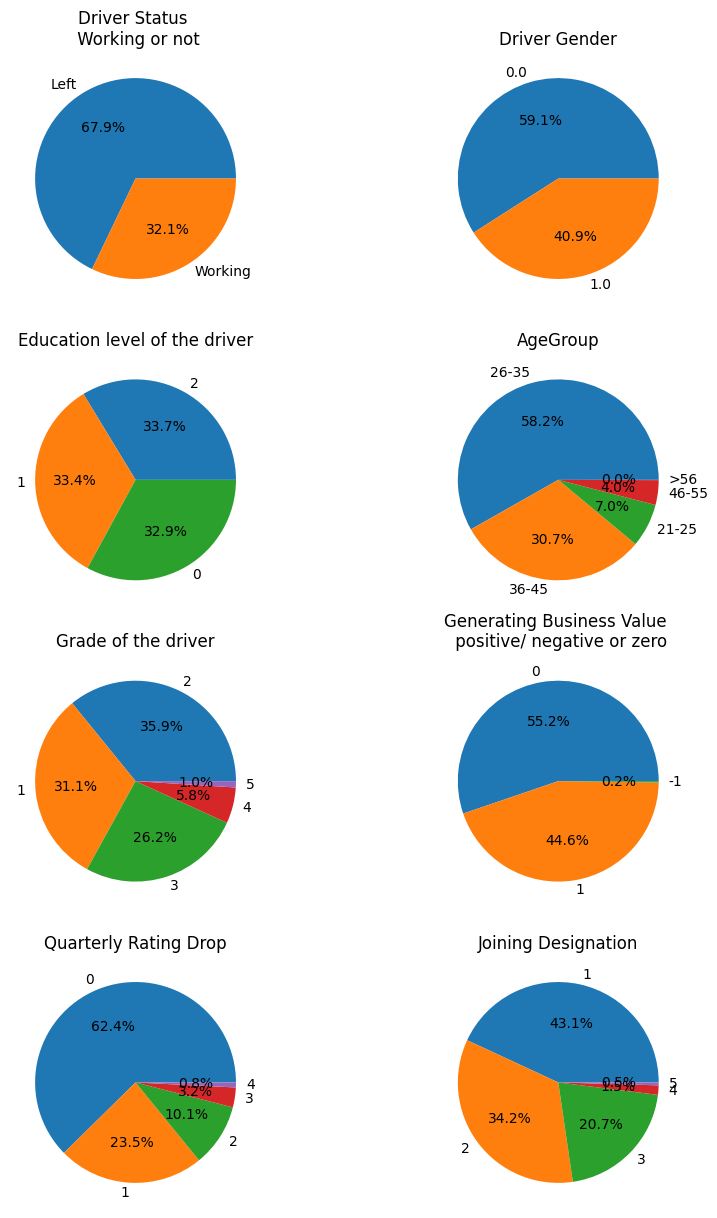

In [ ]:
plt.figure(figsize=(10,15))
plt.subplot(421)
plt.pie(df_grp.DS.value_counts(), labels=df_grp.DS.value_counts().index, autopct='%1.1f%%')
plt.title('Driver Status \n Working or not')
plt.subplot(422)
plt.pie(df_grp.Gender.value_counts(), labels=df_grp.Gender.value_counts().index, autopct='%1.1f%%')
plt.title('Driver Gender')
plt.subplot(423)
plt.pie(df_grp.Education_Level.value_counts(), labels=df_grp.Education_Level.value_counts().index, autopct='%1.1f%%')
plt.title('Education level of the driver')
plt.subplot(424)
plt.pie(df_grp['AgeGroup'].value_counts(), labels=df_grp['AgeGroup'].value_counts().index, autopct='%1.1f%%')
plt.title('AgeGroup')
plt.subplot(425)
plt.pie(df_grp.Grade.value_counts(), labels=df_grp.Grade.value_counts().index, autopct='%1.1f%%')
plt.title('Grade of the driver')
plt.subplot(426)
plt.pie(df_grp.BV.value_counts(), labels=df_grp.BV.value_counts().index, autopct='%1.1f%%')
plt.title('Generating Business Value \n positive/ negative or zero')
plt.subplot(427)
plt.pie(df_grp.ratDrop.value_counts(), labels=df_grp.ratDrop.value_counts().index, autopct='%1.1f%%')
plt.title('Quarterly Rating Drop')
plt.subplot(428)
plt.pie(df_grp['Joining Designation'].value_counts(), labels=df_grp['Joining Designation'].value_counts().index, autopct='%1.1f%%')
plt.title('Joining Designation')
plt.show()

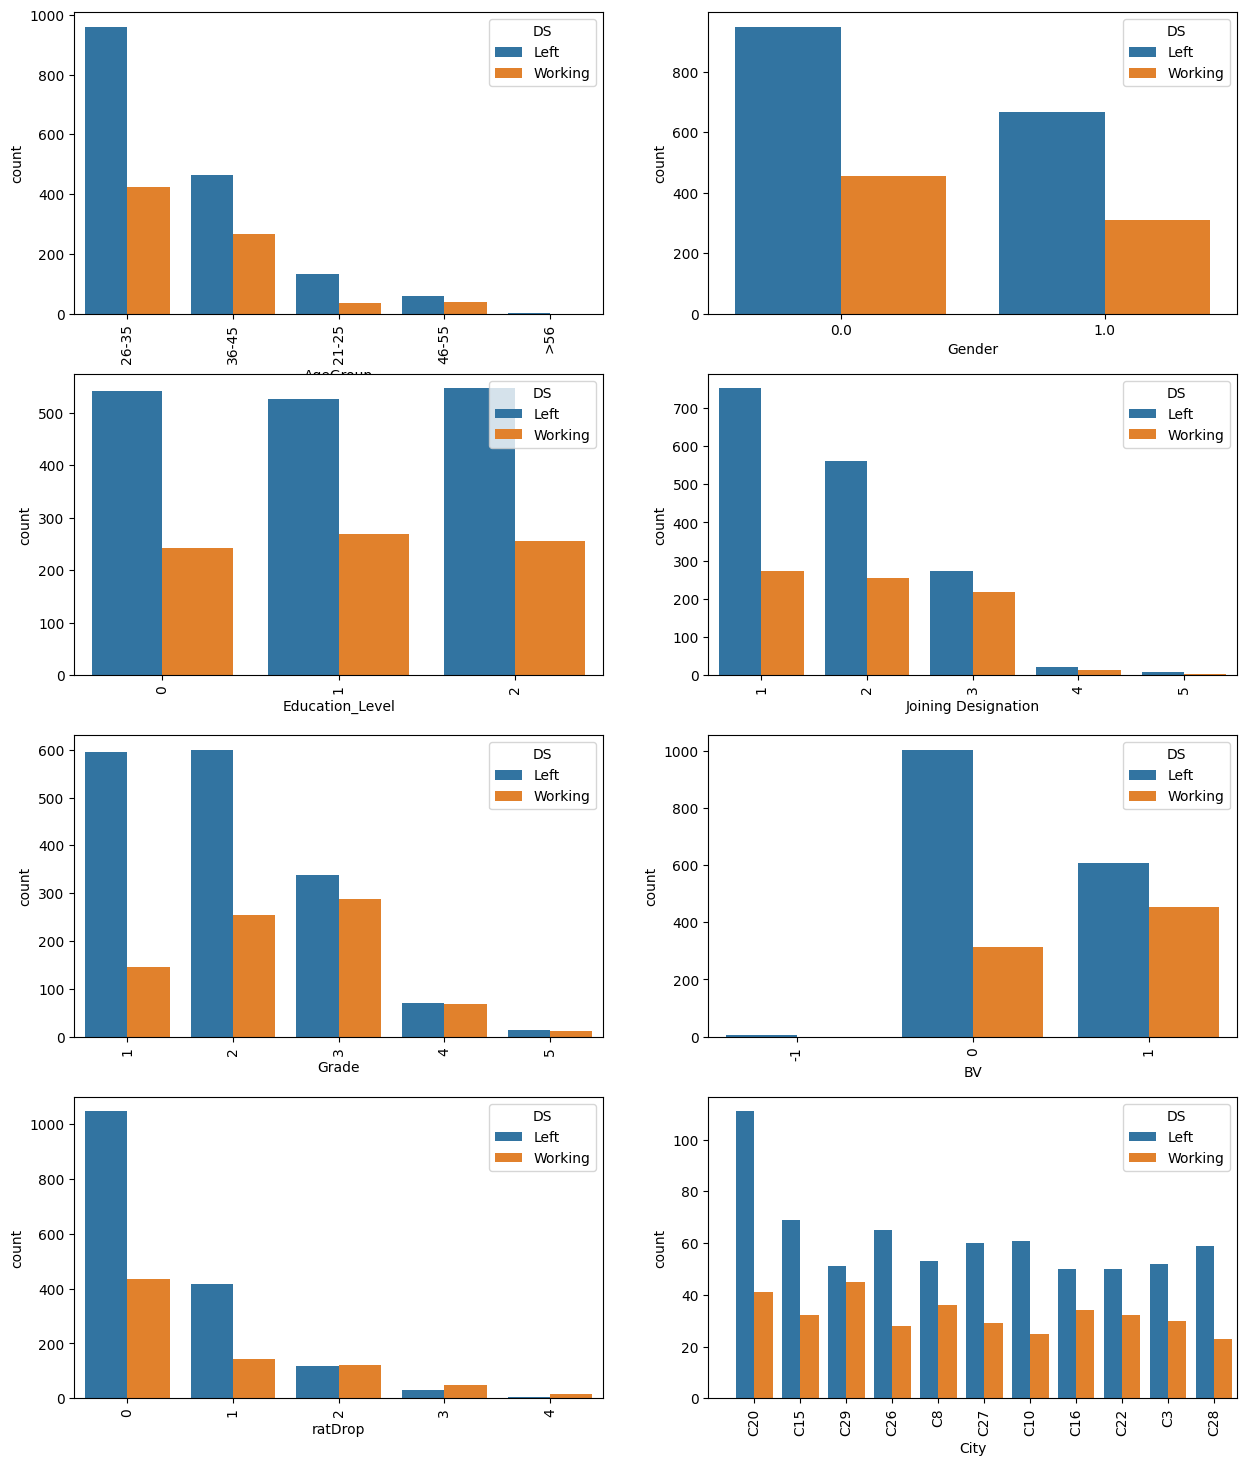

In [ ]:
figsize = (15, 18)
plt.figure(figsize=figsize)
plt.subplot(421)
sns.countplot(x='AgeGroup',hue='DS', data=df_grp)
plt.xticks(rotation=90)
plt.subplot(422)
sns.countplot(x='Gender',hue='DS', data=df_grp)
plt.subplot(423)
sns.countplot(x='Education_Level',hue='DS', data=df_grp)
plt.xticks(rotation=90)
plt.subplot(424)
sns.countplot(x='Joining Designation',hue='DS', data=df_grp)
plt.xticks(rotation=90)
plt.subplot(425)
sns.countplot(x='Grade',hue='DS', data=df_grp)
plt.xticks(rotation=90)
plt.subplot(426)
sns.countplot(x='BV',hue='DS', data=df_grp)
plt.xticks(rotation=90)
plt.subplot(427)
sns.countplot(x='ratDrop',hue='DS', data=df_grp)
plt.xticks(rotation=90)
plt.subplot(428)
sns.countplot(x='City', hue='DS',order=df_grp.City.value_counts().index ,data=df_grp)
plt.xlim(-1,10.5)
plt.xticks(rotation=90)
plt.show()

**Observations:**
- Largest number of driver who left belong to age group 21-35 youngs are leaving
- Gender of driver is no discriminator for drivers leaving
- Education level is no discriminator for drivers leaving
- Number of Drivers with Grade 1, 2 are leaving the group compared to other
- BV with -1, and 0, i.e. more drivers with total business value negative or 0 leave the group
- More number of drivers with joining designation 1, 2 are leaving the group
- Drivers with 0 and 1 rating drops are leaving the group compared to higher ratDrops: performers are leaving

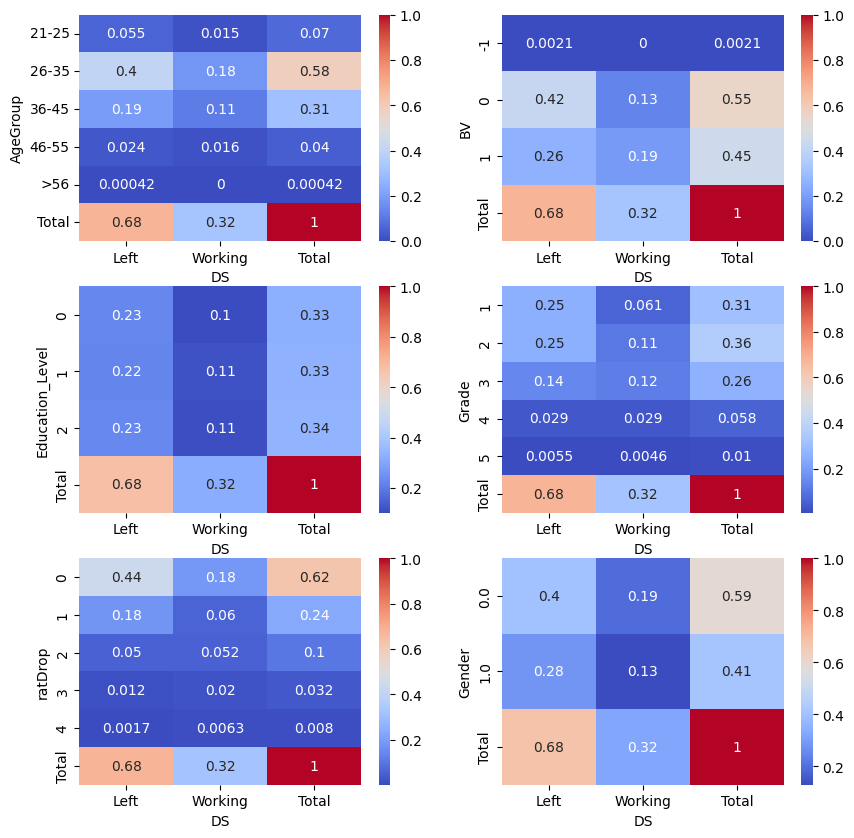

In [ ]:
catCol=['AgeGroup','BV','Education_Level', 'Grade', 'ratDrop', 'Gender']
plt.figure(figsize=(10,10))
for i in catCol:
  plt.subplot(3,2,catCol.index(i)+1)
  sns.heatmap(pd.crosstab(df_grp[i], df_grp.DS, margins=True, margins_name='Total', normalize=True), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
df_grp.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
Age,2381.0,3.380432e+01,5.909102e+00,21.0,30.0,33.0,37.0,58.0
Gender,2381.0,4.094918e-01,4.918433e-01,0.0,0.0,0.0,1.0,1.0
Education_Level,2381.0,1.007560e+00,8.162900e-01,0.0,0.0,1.0,2.0,2.0
Income,2381.0,5.923246e+04,2.829821e+04,10747.0,39104.0,55285.0,75835.0,188418.0
Joining Designation,2381.0,1.820244e+00,8.414334e-01,1.0,1.0,2.0,2.0,5.0
Grade,2381.0,2.097018e+00,9.417017e-01,1.0,1.0,2.0,3.0,5.0
Total Business Value,2381.0,4.586742e+06,9.127115e+06,-1385530.0,0.0,817680.0,4173650.0,95331060.0
Quarterly Rating,2381.0,1.566304e+00,7.196520e-01,1.0,1.0,1.0,2.0,4.0
BV,2381.0,4.435111e-01,5.011132e-01,-1.0,0.0,0.0,1.0,1.0
ratDrop,2381.0,5.653087e-01,8.577610e-01,0.0,0.0,0.0,1.0,4.0


In [ ]:
df_grp.describe(include='object').T

,count,unique,top,freq
City,2381,29,C20,152
AgeGroup,2381,5,26-35,1386
DS,2381,2,Left,1616


Distribution of vars, using histplot.

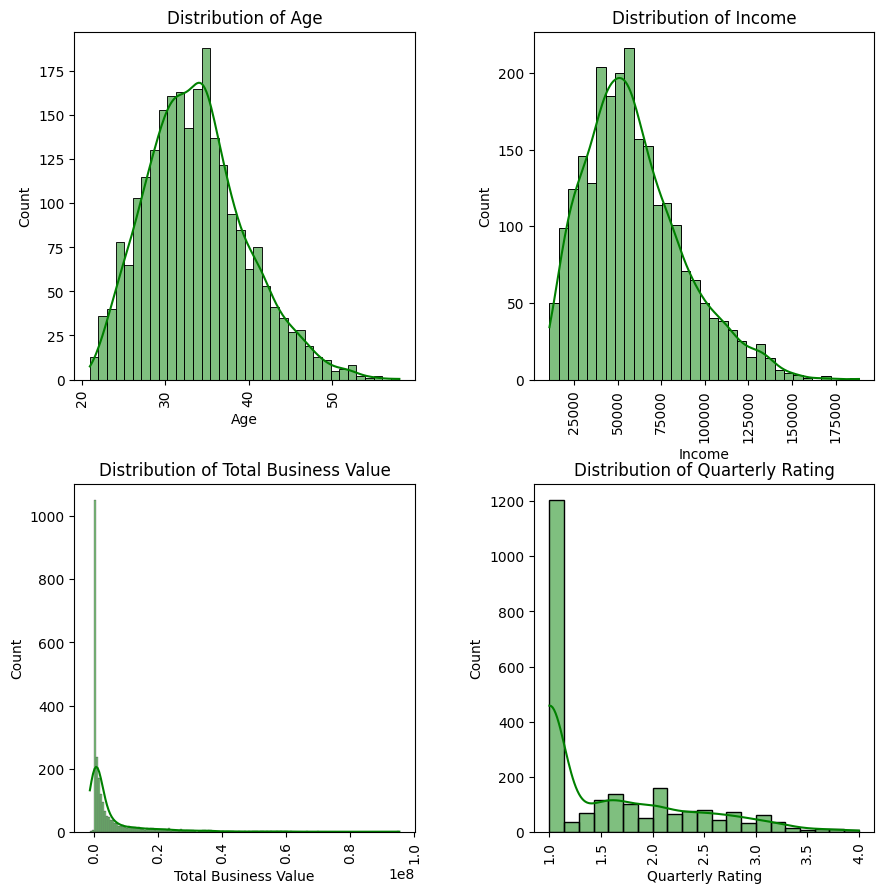

In [ ]:
numCols=['Age', 'Income', 'Total Business Value', 'Quarterly Rating']
plt.figure(figsize=(10,10)).tight_layout()
for i in numCols:
  plt.subplot(2,2,numCols.index(i)+1)
  sns.histplot(x=df_grp[i], kde=True,color='g' )
  plt.xticks(rotation=90)
  plt.title(f'Distribution of {i}')
plt.subplots_adjust(left=0.1, right=0.9,
                    top=0.9, bottom=0.1,
                    wspace=0.35, hspace=0.3)
plt.show()

**Distribution:**
- Distribution of age, and income of drivers are normal, whereas Total Business Value, and Quarterly rating are skewed

**Bivariate visuals using scatter plots**

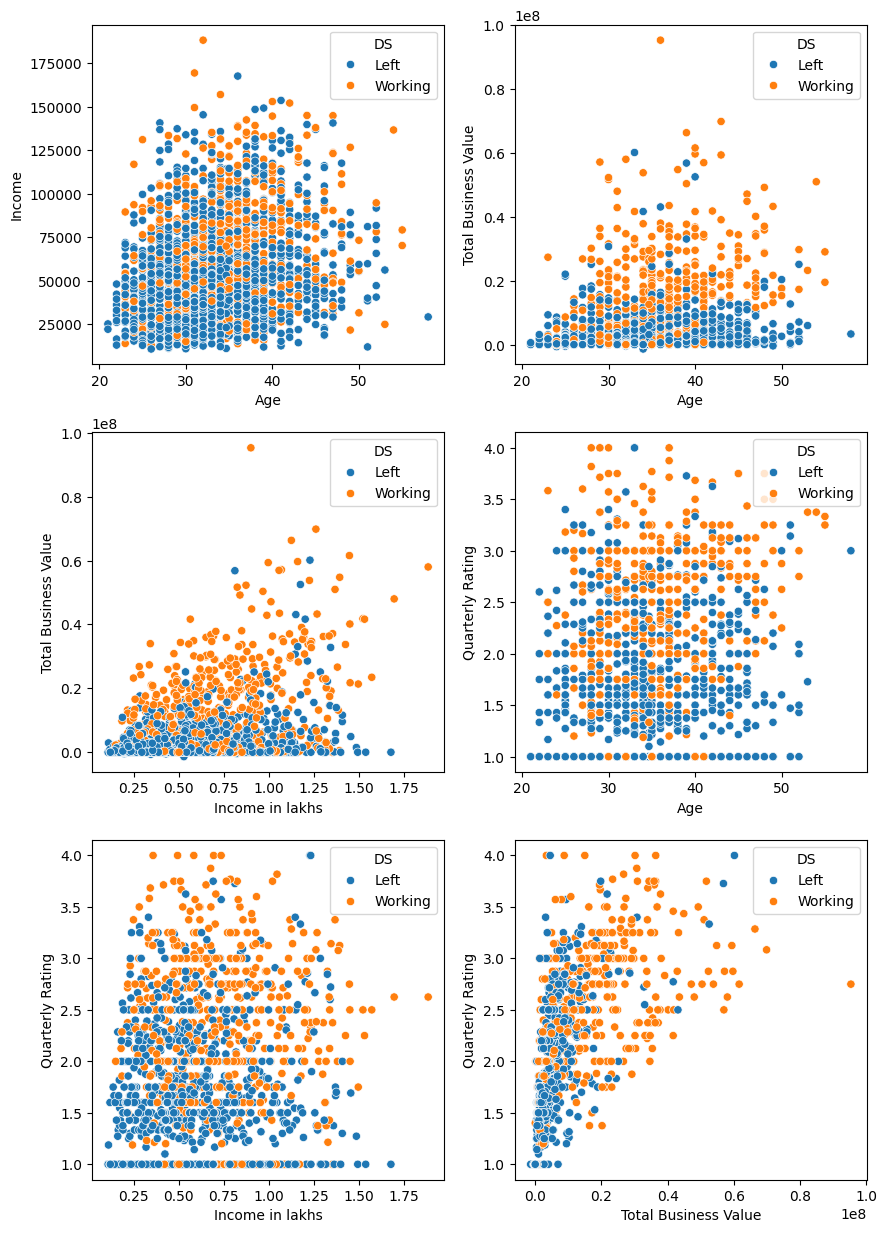

In [ ]:
plt.figure(figsize=(10,15))
plt.subplot(321)
sns.scatterplot(x='Age', y='Income', data=df_grp, hue='DS')
plt.subplot(322)
sns.scatterplot(x='Age', y='Total Business Value', data=df_grp, hue='DS')
plt.subplot(323)
sns.scatterplot(x=df_grp['Income']/100000, y='Total Business Value', data=df_grp, hue='DS')
plt.xlabel('Income in lakhs')
plt.subplot(324)
sns.scatterplot(x='Age', y='Quarterly Rating', data=df_grp, hue='DS')
plt.subplot(325)
sns.scatterplot(x=df_grp['Income']/100000, y='Quarterly Rating', data=df_grp, hue='DS')
plt.xlabel('Income in lakhs')
plt.subplot(326)
sns.scatterplot(x='Total Business Value', y='Quarterly Rating', data=df_grp, hue='DS')
plt.show()

**Insights:**
- Drivers with lower to moderate income, and lower age tend to leave OLA
- Drivers generating lower total business value across all age groups/ income groups tend to leave OLA
- Drivers across age groups irrespective of quarterly rating tend to leave OLA
- Drivers with upto moderate income and lower rating tend to leave OLA
- Drivers with lower total business value, across spectrum of quarterly ratings tend to leave OLA, more pronounced toward lower to moderate ratings.

# Data preprocessing:

Outliers:

In [ ]:
df_grp.select_dtypes(include='number').columns

Index(['Age', 'Gender', 'Education_Level', 'Income', 'Joining Designation',
       'Grade', 'Total Business Value', 'Quarterly Rating', 'BV', 'ratDrop'],
      dtype='object')

In [ ]:
numCols=['Age', 'Income', 'Total Business Value', 'Quarterly Rating']

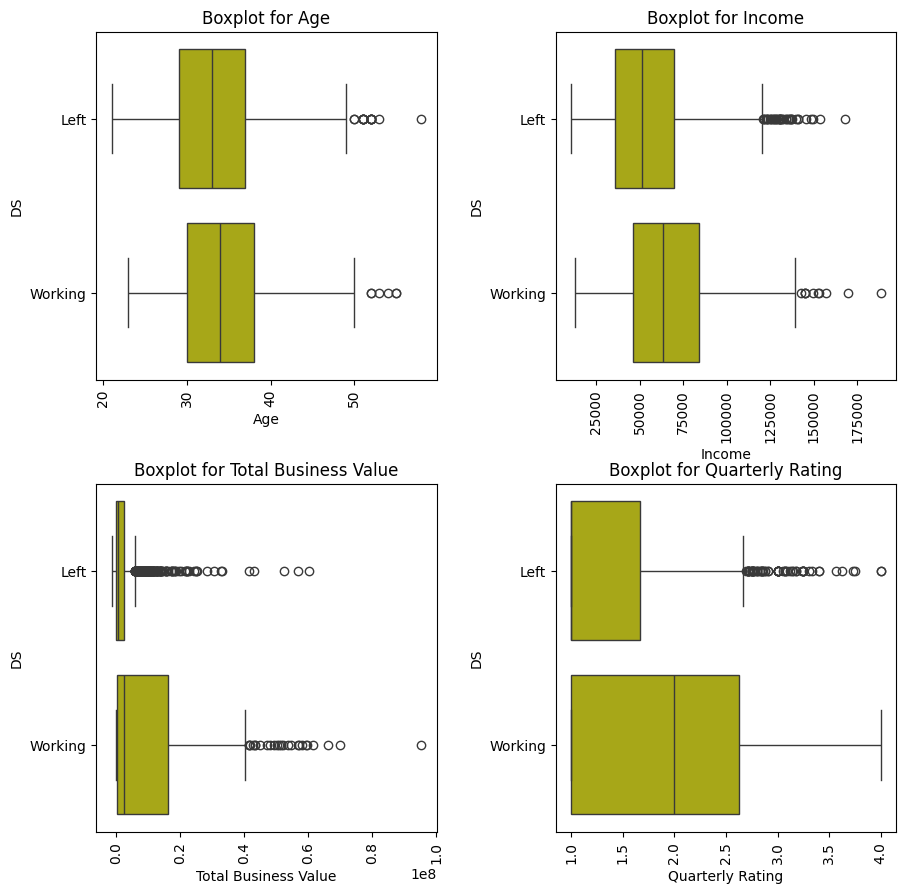

In [ ]:
plt.figure(figsize=(10,10)).tight_layout()
for i in numCols:
  plt.subplot(2,2,numCols.index(i)+1)
  sns.boxplot(x=df_grp[i],y=df_grp.DS, color='y')
  plt.xticks(rotation=90)
  plt.title(f'Boxplot for {i}')
plt.subplots_adjust(left=0.1, right=0.9,
                    top=0.9, bottom=0.1,
                    wspace=0.35, hspace=0.3)
plt.show()

**Insights:**
- Distribution for 'Age', and 'Income' are similar for 'Left', and 'Working'.
- Outliers seen for Total Business Value, for both classes, 'Left', and 'Working'. IQR for 'Left' is very small against that of 'Working'.
- Outliers are seen for Quarterly Rating for 'Left', and IQR for 'Left' is small compared to 'Working'.

Determining percentage of outliers for diffetent numeric columns, using z-score

In [ ]:
df_grp['z_score_Age']=np.abs((df_grp.Age-df_grp.Age.mean())/df_grp.Age.std())
df_grp['z_score_Income']=np.abs((df_grp.Income-df_grp.Income.mean())/df_grp.Income.std())
df_grp['z_score_Total Business Value']=np.abs((df_grp['Total Business Value']-df_grp['Total Business Value'].mean())/df_grp['Total Business Value'].std())
df_grp['z_score_Quarterly Rating']=np.abs((df_grp['Quarterly Rating']-df_grp['Quarterly Rating'].mean())/df_grp['Quarterly Rating'].std())

Maximum percentage of outliers exist in column 'Total Business Value', which is 2.69%. As per machine learning norms less than 5% outlier population can be conviniently ignored, with much implications on outcome.

In [ ]:
OL_Age=(df_grp.z_score_Age>3).sum()/df_grp.shape[0]*100
OL_Income=(df_grp.z_score_Income>3).sum()/df_grp.shape[0]*100
OL_TBV=(df_grp['z_score_Total Business Value']>3).sum()/df_grp.shape[0]*100
OL_QR=(df_grp['z_score_Quarterly Rating']>3).sum()/df_grp.shape[0]*100
for i in ['OL_Age', 'OL_Income', 'OL_TBV', 'OL_QR']:
  print(f"% of outliers {i[3:]} is {eval(i):.2f}%.")

% of outliers Age is 0.59%.
% of outliers Income is 0.59%.
% of outliers TBV is 2.69%.
% of outliers QR is 0.71%.


In [ ]:
df_grp.shape

(2381, 21)

In [ ]:
df_grp.select_dtypes(include='number').columns

Index(['Age', 'Gender', 'Education_Level', 'Income', 'Joining Designation',
       'Grade', 'Total Business Value', 'Quarterly Rating', 'BV', 'ratDrop',
       'z_score_Age', 'z_score_Income', 'z_score_Total Business Value',
       'z_score_Quarterly Rating'],
      dtype='object')

Dropping columns like z_score. . . ,

In [ ]:
df_grp.drop(['z_score_Age', 'z_score_Income', 'z_score_Total Business Value', 'z_score_Quarterly Rating'], axis=1, inplace=True)

In [ ]:
df_grp.columns

Index(['MMM-YY', 'Age', 'Gender', 'City', 'Education_Level', 'Income',
       'Dateofjoining', 'LastWorkingDate', 'Joining Designation', 'Grade',
       'Total Business Value', 'Quarterly Rating', 'BV', 'ratDrop', 'DStatus',
       'AgeGroup', 'DS'],
      dtype='object')

In [ ]:
df_grp.select_dtypes(include='object').columns

Index(['City', 'AgeGroup', 'DS'], dtype='object')

Dropping 'DS', and 'AgeGroup', as they are derived from DStatus', and 'Age', not required in further analyses

In [ ]:
df_grp.drop(columns=['AgeGroup', 'DS'], inplace=True)

Dropping other columns like dates/ designation etc.

In [ ]:
df_grp.drop(columns=['Joining Designation', 'MMM-YY', 'Dateofjoining', 'LastWorkingDate', 'Joining Designation'], inplace=True)

In [ ]:
df_grp.columns

Index(['Age', 'Gender', 'City', 'Education_Level', 'Income', 'Grade',
       'Total Business Value', 'Quarterly Rating', 'BV', 'ratDrop', 'DStatus'],
      dtype='object')

correlation amongst columns

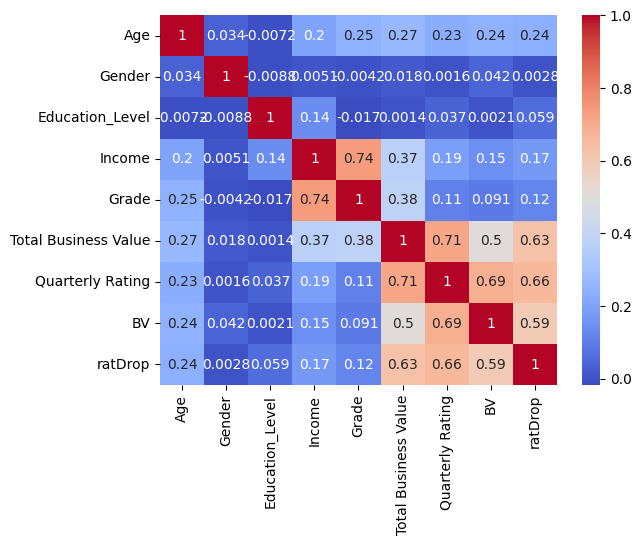

In [ ]:
sns.heatmap(df_grp.select_dtypes(include='number').corr(), cmap='coolwarm', annot=True)
plt.show()

Encoding city names:

In [ ]:
rpl={'C23':23, 'C7':7, 'C13':13, 'C9':9, 'C11':11, 'C2':2, 'C19':19, 'C26':26, 'C20':28, 'C17':17,
       'C29':29, 'C10':10, 'C24':24, 'C14':14, 'C6':6, 'C28':28, 'C5':5, 'C18':18, 'C27':27, 'C15':15,
       'C8':8, 'C25':25, 'C21':21, 'C1':1, 'C4':4, 'C3':3, 'C16':16, 'C22':22, 'C12':12}
df_grp.City=df_grp.City.map(rpl)

In [ ]:
df_grp.City.unique()

array([23,  7, 13,  9, 11,  2, 19, 26, 28, 17, 29, 10, 24, 14,  6,  5, 18,
       27, 15,  8, 25, 21,  1,  4,  3, 16, 22, 12])

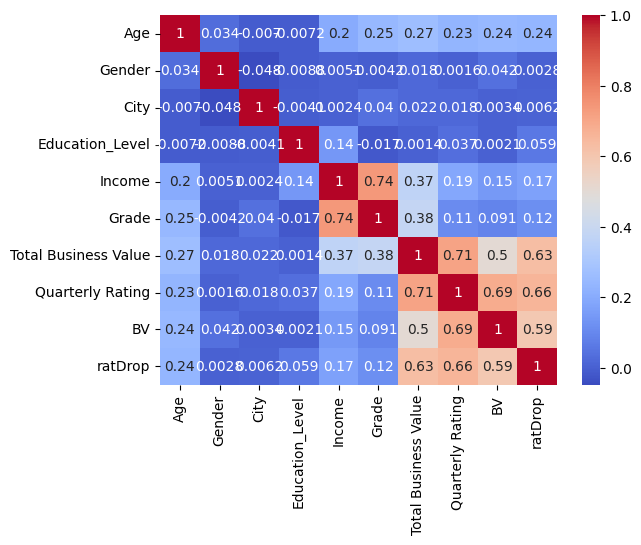

In [ ]:
sns.heatmap(df_grp.select_dtypes(include='number').corr(), cmap='coolwarm', annot=True)
plt.show()

Splitting data into Target and Stimuli

In [ ]:
X=df_grp.drop(columns=['DStatus'])
y=df_grp.DStatus

In [ ]:
y=df_grp.DStatus.apply(lambda x: 1 if x==False else 0)

The target var 'DriverStatus' is significantly biassed towards 'False' (count of drivers who left OLA).

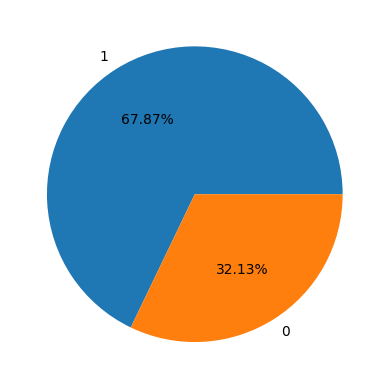

In [ ]:
plt.pie(y.value_counts(), labels=y.value_counts().index, autopct='%.2f%%')
plt.show()

Applying SMOTE to balance the dataset:

In [ ]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X, y=smote.fit_resample(X,y)

Dataset post SMOTE resampling:

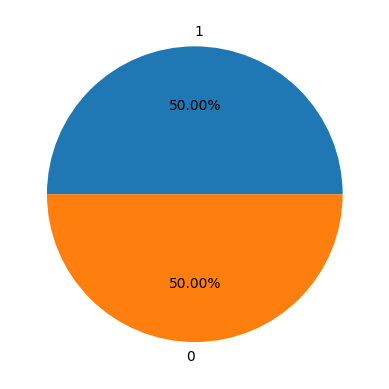

In [ ]:
plt.pie(y.value_counts(), labels=y.value_counts().index, autopct='%.2f%%')
plt.show()

Normalizing the data, using StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [ ]:
X_scaled=pd.DataFrame(X_scaled, columns=X.columns)

In [ ]:
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,3232.0,-1.312481e-15,1.000155,-2.293013,-0.706127,-0.000844,0.528627,4.230853
Gender,3232.0,9.893076e-18,1.000155,-0.870600,-0.870600,-0.870600,1.257004,1.257004
City,3232.0,6.265615e-17,1.000155,-1.748669,-0.804950,0.020804,0.964523,1.554348
Education_Level,3232.0,-1.055261e-16,1.000155,-1.176432,-1.176432,0.084254,1.344939,1.344939
Income,3232.0,-2.989908e-16,1.000155,-1.798169,-0.736278,-0.129363,0.576372,4.512725
Grade,3232.0,-4.836615e-17,1.000155,-1.210120,-1.210120,-0.120371,0.969377,3.148874
Total Business Value,3232.0,-1.758769e-17,1.000155,-0.704102,-0.572310,-0.465272,0.051485,8.495614
Quarterly Rating,3232.0,-1.494954e-16,1.000155,-0.883444,-0.883444,-0.322865,0.751579,3.040610
BV,3232.0,7.914461e-17,1.000155,-2.932820,-0.942296,-0.942296,1.048228,1.048228
ratDrop,3232.0,-1.319077e-17,1.000155,-0.676371,-0.676371,-0.676371,0.472962,3.920962


Splitting data into train and test sets

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X_scaled, y, test_size=0.25, random_state=42)

# Creating model/ ROC-AUC analysis

Random forest classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix, classification_report

Hyper parameter tuning:

In [ ]:
perf=[]
for i in range(25, 250, 25):
  for l in ['gini', 'entropy']:
    RFC=RandomForestClassifier(n_estimators=i, max_depth=3, criterion=l, random_state=42)
    RFC.fit(X_train, y_train)
    perf.append([i, l, roc_auc_score(y_train, RFC.predict(X_train))])

In [ ]:
perf=pd.DataFrame(perf, columns=['n_estimators', 'criterion', 'train_auc'])

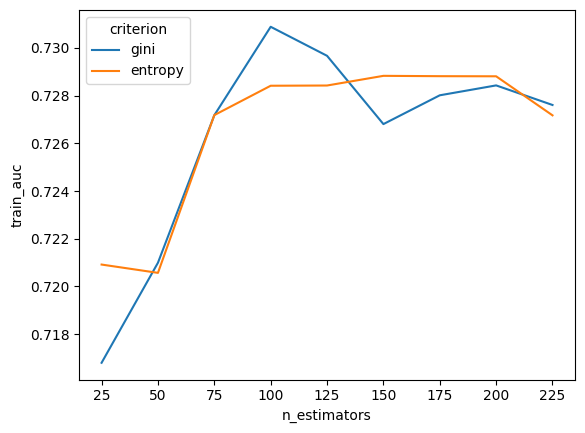

In [ ]:
sns.lineplot(x='n_estimators', y='train_auc', hue='criterion', data=perf)
plt.show()

hyper parameters tuning for Random Forest Classifier yielded optimal params:
- n_estimators=150, max_depth=3, criterion=entropy, random_state=42

In [ ]:
RFC_Best=RandomForestClassifier(n_estimators=150, criterion='entropy' ,min_samples_leaf=3, random_state=42)
RFC_Best.fit(X_train, y_train)
y_pred_RFC_train=RFC_Best.predict(X_train)
y_pred_RFC_test=RFC_Best.predict(X_test)

In [ ]:
print('RFC_Best Confusion_matrix train: \n',confusion_matrix(y_train, y_pred_RFC_train))
print('RFC_Best Confusion_matrix test: \n',confusion_matrix(y_test, y_pred_RFC_test))
print('RFC_Best Classification report train: \n', classification_report(y_train, y_pred_RFC_train))
print('RFC_Best Classification report test: \n', classification_report(y_test, y_pred_RFC_test))

RFC_Best Confusion_matrix train: 
 [[1103  102]
 [  37 1182]]
RFC_Best Confusion_matrix test: 
 [[303 108]
 [ 54 343]]
RFC_Best Classification report train: 
               precision    recall  f1-score   support

           0       0.97      0.92      0.94      1205
           1       0.92      0.97      0.94      1219

    accuracy                           0.94      2424
   macro avg       0.94      0.94      0.94      2424
weighted avg       0.94      0.94      0.94      2424

RFC_Best Classification report test: 
               precision    recall  f1-score   support

           0       0.85      0.74      0.79       411
           1       0.76      0.86      0.81       397

    accuracy                           0.80       808
   macro avg       0.80      0.80      0.80       808
weighted avg       0.81      0.80      0.80       808



Values for precision and recall test:0- (P- .85, R- .74), 1- (P- .76,R- .81).

**Feature importance:**

In [ ]:
FI_RFC=pd.DataFrame(X_train.columns, RFC_Best.feature_importances_)
FI_RFC.reset_index(inplace=True)
FI_RFC.columns=['Importance', 'Feature']
FI_RFC.sort_values(by='Importance', ascending=False, inplace=True)

'Total Business Value' has highest importance, closely followed by 'Income', 'Quarterly Rating', 'Age' and so on:

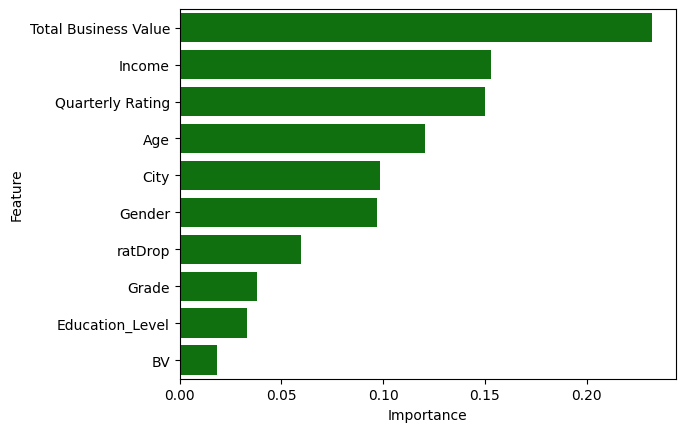

In [ ]:
sns.barplot(x='Importance', y='Feature', data=FI_RFC, color='g')
plt.show()

In [ ]:
RFC_Best.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 150,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [ ]:
print(f"Train AUC_Score_RFC: {roc_auc_score(y_train, y_pred_RFC_train)}")
print(f"Test AUC_Score_RFC: {roc_auc_score(y_test, y_pred_RFC_test)}")

Train AUC_Score_RFC: 0.9424999744706054
Test AUC_Score_RFC: 0.8006030631193808


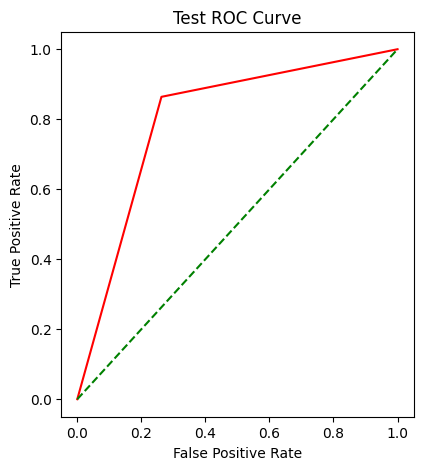

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(121)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_RFC_test)
plt.plot(fpr, tpr, color='red')
plt.plot([0, 1], [0, 1], color='green', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Test ROC Curve')
plt.show()

**Gradient boosting**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
GBC=GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=3, random_state=42)

In [ ]:
perf=[]
for i in range(100, 250, 50):
  for k in ['log_loss', 'exponential']:
    for lr in [0.05,0.1, 0.5]:
      GBC=GradientBoostingClassifier(n_estimators=i,learning_rate=lr, loss=k, random_state=42)
      GBC.fit(X_train, y_train)
      perf.append([i, k, lr, roc_auc_score(y_train, GBC.predict(X_train))])

In [ ]:
perf=pd.DataFrame(perf, columns=['n_estimators', 'loss', 'learning_rate', 'train_auc'])

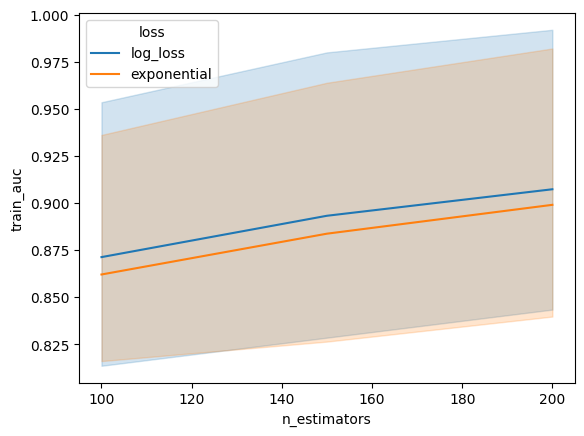

In [ ]:
sns.lineplot(x='n_estimators', y='train_auc', hue='loss', data=perf)
plt.show()

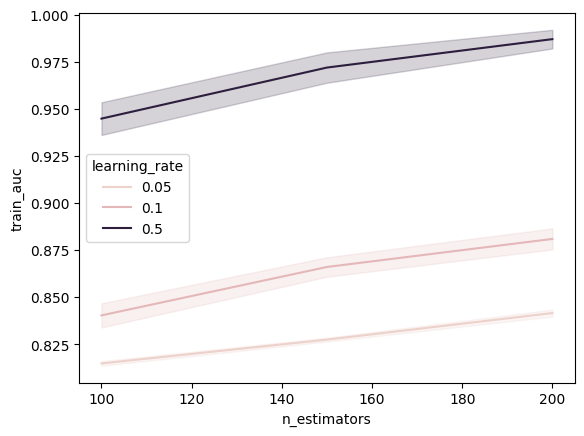

In [ ]:
sns.lineplot(x='n_estimators', y='train_auc', hue='learning_rate', data=perf)
plt.show()

selecting n_estimators as 200, loss=log_loss, learning_rate as 0.1, for optimal model.

In [ ]:
GBC_Best=GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, loss='log_loss', random_state=42)
GBC_Best.fit(X_train, y_train)
y_pred_GBC_train=GBC_Best.predict(X_train)
y_pred_GBC_test=GBC_Best.predict(X_test)

In [ ]:
print('GBC_Best Confusion_matrix train: \n',confusion_matrix(y_train, y_pred_GBC_train))
print('GBC_Best Confusion_matrix test: \n',confusion_matrix(y_test, y_pred_GBC_test))
print('GBC_Best Classification report train: \n', classification_report(y_train, y_pred_GBC_train))
print('GBC_Best Classification report test: \n', classification_report(y_test, y_pred_GBC_test))

GBC_Best Confusion_matrix train: 
 [[ 999  206]
 [  68 1151]]
GBC_Best Confusion_matrix test: 
 [[301 110]
 [ 48 349]]
GBC_Best Classification report train: 
               precision    recall  f1-score   support

           0       0.94      0.83      0.88      1205
           1       0.85      0.94      0.89      1219

    accuracy                           0.89      2424
   macro avg       0.89      0.89      0.89      2424
weighted avg       0.89      0.89      0.89      2424

GBC_Best Classification report test: 
               precision    recall  f1-score   support

           0       0.86      0.73      0.79       411
           1       0.76      0.88      0.82       397

    accuracy                           0.80       808
   macro avg       0.81      0.81      0.80       808
weighted avg       0.81      0.80      0.80       808



Feature Importance GBC

In [ ]:
FI_GBC=pd.DataFrame(X_train.columns, GBC_Best.feature_importances_)
FI_GBC.reset_index(inplace=True)
FI_GBC.columns=['Importance', 'Feature']
FI_GBC.sort_values(by='Importance', ascending=False, inplace=True)

GBC delivers 'Total Business Value' as the feature with highest weight, way ahead of 'Quarterly Rating','Gender', 'ratDrop', 'Age', etc.. To be noted 'Income' appear with much lower weight.

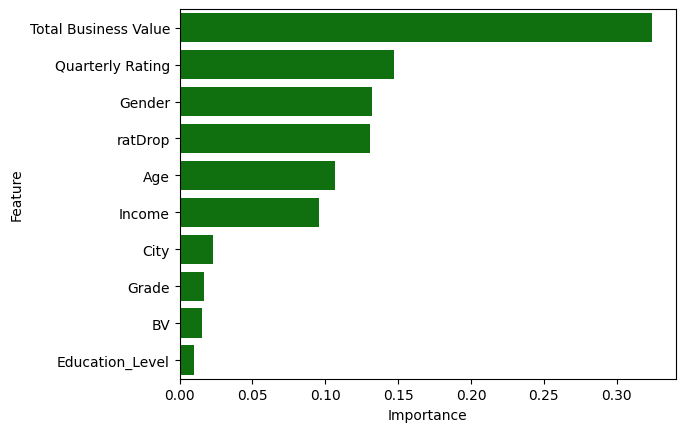

In [ ]:
sns.barplot(x='Importance', y='Feature', data=FI_GBC, color='g')
plt.show()

In [ ]:
GBC_Best.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'log_loss',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 200,
 'n_iter_no_change': None,
 'random_state': 42,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [ ]:
print(f"Train AUC_Score_GBC: {roc_auc_score(y_train, y_pred_GBC_train)}")
print(f"Test AUC_Score_GBC: {roc_auc_score(y_test, y_pred_GBC_test)}")

Train AUC_Score_GBC: 0.886631107056665
Test AUC_Score_GBC: 0.8057266481580221


Printing ROC_AUC curve for GBC_Best

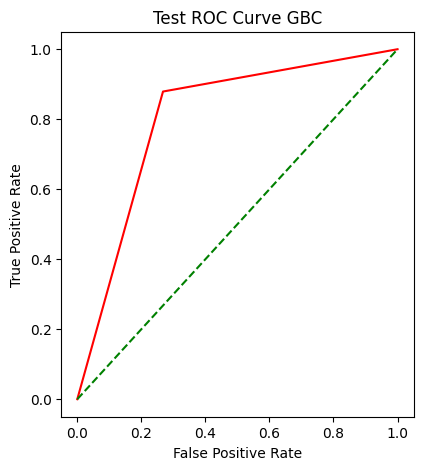

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(121)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_GBC_test)
plt.plot(fpr, tpr, color='red')
plt.plot([0, 1], [0, 1], color='green', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Test ROC Curve GBC')
plt.show()

**LightGBM**

In [ ]:
from lightgbm import LGBMClassifier
LGBM=LGBMClassifier(n_estimators=200, boosting_type='gbdt', learning_rate=0.05, random_state=42)

In [ ]:
perf=[]
for i in range(50, 1000, 50):
  for k in [0.05, 0.1, 0.5]:
    LGBM=LGBMClassifier(n_estimators=i, max_depth=8, num_leaves=100, learning_rate=k, boosting_type='gbdt', random_state=42)
    LGBM.fit(X_train, y_train)
    perf.append([i, k, roc_auc_score(y_train, LGBM.predict(X_train))])

In [ ]:
perf=pd.DataFrame(perf, columns=['n_estimators', 'learning_rate', 'train_auc'])

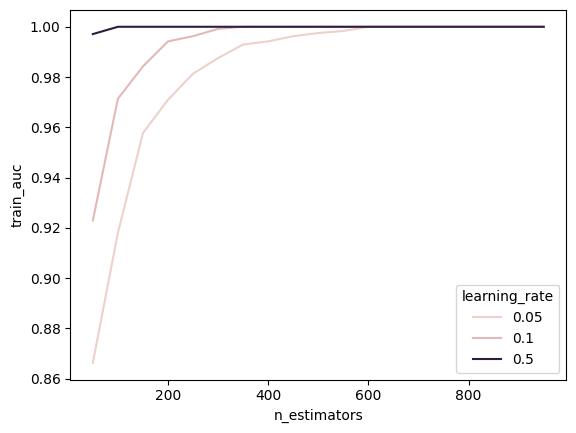

In [ ]:
sns.lineplot(x='n_estimators', y='train_auc', hue='learning_rate', data=perf)
plt.show()

selecting n_estimators=100, learning_rate=0.1 avoiding overfitting accepting train_auc as 0.93

In [ ]:
LGBM_Opt=LGBMClassifier(n_estimators=100, max_depth=8, num_leaves=100, learning_rate=0.1, boosting_type='gbdt', random_state=42)
LGBM_Opt.fit(X_train, y_train)
y_pred_LGBM_train=LGBM_Opt.predict(X_train)
y_pred_LGBM_test=LGBM_Opt.predict(X_test)

In [ ]:
print('LGBM_Opt Confusion_matrix train: \n',confusion_matrix(y_train, y_pred_LGBM_train))
print('LGBM_Opt Confusion_matrix test: \n',confusion_matrix(y_test, y_pred_LGBM_test))
print('LGBM_Opt Classification report train: \n', classification_report(y_train, y_pred_LGBM_train))
print('LGBM_Opt Classification report test: \n', classification_report(y_test, y_pred_LGBM_test))

LGBM_Opt Confusion_matrix train: 
 [[1139   66]
 [   3 1216]]
LGBM_Opt Confusion_matrix test: 
 [[313  98]
 [ 62 335]]
LGBM_Opt Classification report train: 
               precision    recall  f1-score   support

           0       1.00      0.95      0.97      1205
           1       0.95      1.00      0.97      1219

    accuracy                           0.97      2424
   macro avg       0.97      0.97      0.97      2424
weighted avg       0.97      0.97      0.97      2424

LGBM_Opt Classification report test: 
               precision    recall  f1-score   support

           0       0.83      0.76      0.80       411
           1       0.77      0.84      0.81       397

    accuracy                           0.80       808
   macro avg       0.80      0.80      0.80       808
weighted avg       0.80      0.80      0.80       808



In [ ]:
print(f"Train AUC_Score_LGBM: {roc_auc_score(y_train, y_pred_LGBM_train)}")
print(f"Test AUC_Score_LGBM: {roc_auc_score(y_test, y_pred_LGBM_test)}")

Train AUC_Score_LGBM: 0.9713835910667542
Test AUC_Score_LGBM: 0.8026929464904056


In [ ]:
GI_LGBM=pd.DataFrame(LGBM_Opt.feature_name_, LGBM_Opt.feature_importances_)
GI_LGBM.reset_index(inplace=True)
GI_LGBM.columns=['Importance', 'Feature']
GI_LGBM.sort_values(by='Importance', ascending=False, inplace=True)

In [ ]:
GI_LGBM.head()

,Importance,Feature
4,910,Income
6,783,Total_Business_Value
0,753,Age
2,545,City
7,434,Quarterly_Rating


Interesting to note the most important feature for LGBM is 'Income', followed by 'Total Business Value', 'Age' etc. in that order.

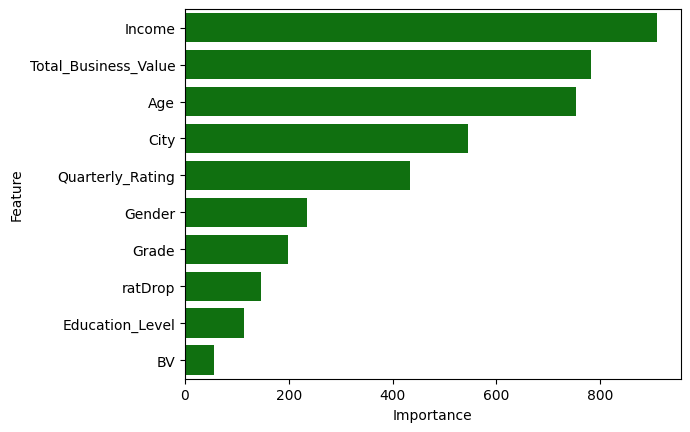

In [ ]:
sns.barplot(x='Importance', y='Feature', data=GI_LGBM, color='g')
plt.show()

In [ ]:
LGBM_Opt.get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': 8,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'num_leaves': 100,
 'objective': None,
 'random_state': 42,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0}

XGBoost

In [ ]:
from xgboost import XGBClassifier
XGB=XGBClassifier(n_estimators=200, learning_rate=0.2, random_state=42)
XGB.fit(X_train, y_train)
y_pred_XGB_train=XGB.predict(X_train)
y_pred_XGB_test=XGB.predict(X_test)

In [ ]:
print('train XGB\n',confusion_matrix(y_train, y_pred_XGB_train))
print('test XGB\n',confusion_matrix(y_test, y_pred_XGB_test))

train XGB
 [[1195   10]
 [   0 1219]]
test XGB
 [[314  97]
 [ 63 334]]


In [ ]:
print('train XGB\n',classification_report(y_train, y_pred_XGB_train))
print('test XGB\n',classification_report(y_test, y_pred_XGB_test))

train XGB
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      1205
           1       0.99      1.00      1.00      1219

    accuracy                           1.00      2424
   macro avg       1.00      1.00      1.00      2424
weighted avg       1.00      1.00      1.00      2424

test XGB
               precision    recall  f1-score   support

           0       0.83      0.76      0.80       411
           1       0.77      0.84      0.81       397

    accuracy                           0.80       808
   macro avg       0.80      0.80      0.80       808
weighted avg       0.80      0.80      0.80       808



In [ ]:
print(f"Train AUC_Score_XGB: {roc_auc_score(y_train, y_pred_XGB_train)}")
print(f"Test AUC_Score_XGB: {roc_auc_score(y_test, y_pred_XGB_test)}")

Train AUC_Score_XGB: 0.995850622406639
Test AUC_Score_XGB: 0.8026500456587423


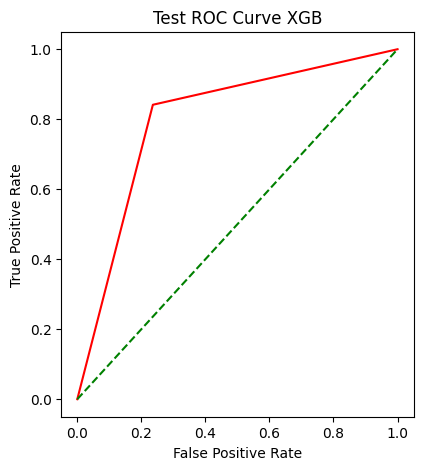

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(121)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_XGB_test)
plt.plot(fpr, tpr, color='red')
plt.plot([0, 1], [0, 1], color='green', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Test ROC Curve XGB')
plt.show()

In [ ]:
FI_XGB= pd.DataFrame(XGB.feature_names_in_, XGB.feature_importances_)
FI_XGB.reset_index(inplace=True)
FI_XGB.columns=['Importance', 'Feature']
FI_XGB.sort_values(by='Importance', ascending=False, inplace=True)

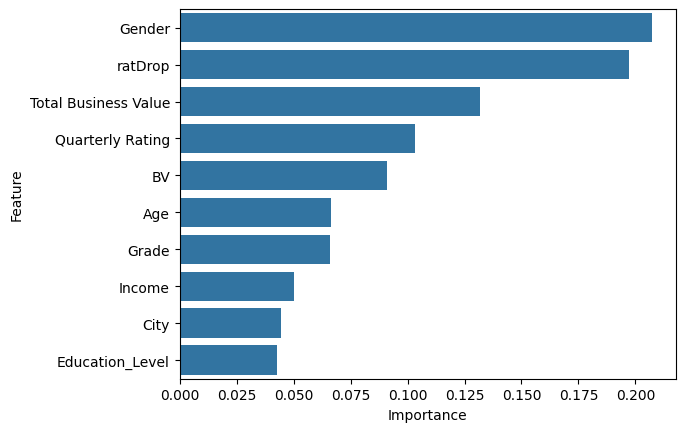

In [ ]:
sns.barplot(x='Importance', y='Feature', data=FI_XGB)
plt.show()

**ADABoost**

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
ABC=AdaBoostClassifier(n_estimators=80, learning_rate=0.84, random_state=42)
ABC.fit(X_train, y_train)
y_pred_ABC_train=ABC.predict(X_train)
y_pred_ABC_test=ABC.predict(X_test)

In [ ]:
print('train ABC\n',confusion_matrix(y_train, y_pred_ABC_train))
print('test ABC\n',confusion_matrix(y_test, y_pred_ABC_test))

train ABC
 [[ 797  408]
 [ 100 1119]]
test ABC
 [[264 147]
 [ 42 355]]


In [ ]:
print('train ABC\n',classification_report(y_train, y_pred_ABC_train))
print('test ABC\n',classification_report(y_test, y_pred_ABC_test))

train ABC
               precision    recall  f1-score   support

           0       0.89      0.66      0.76      1205
           1       0.73      0.92      0.82      1219

    accuracy                           0.79      2424
   macro avg       0.81      0.79      0.79      2424
weighted avg       0.81      0.79      0.79      2424

test ABC
               precision    recall  f1-score   support

           0       0.86      0.64      0.74       411
           1       0.71      0.89      0.79       397

    accuracy                           0.77       808
   macro avg       0.78      0.77      0.76       808
weighted avg       0.79      0.77      0.76       808



In [ ]:
FI_ABC= pd.DataFrame(ABC.feature_names_in_, ABC.feature_importances_)
FI_ABC.reset_index(inplace=True)
FI_ABC.columns=['Importance', 'Feature']
FI_ABC.sort_values(by='Importance', ascending=False, inplace=True)

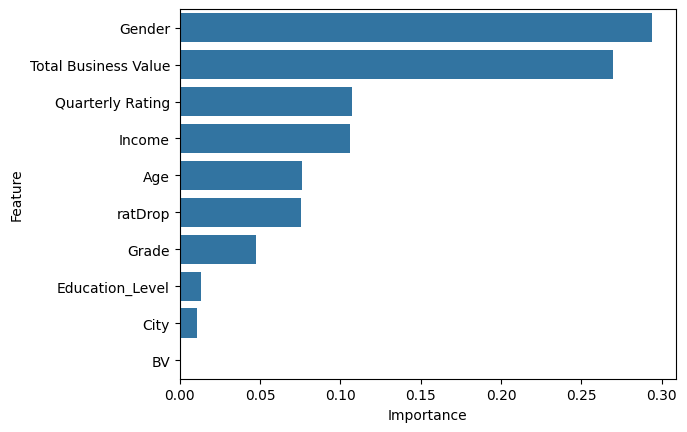

In [ ]:
sns.barplot(x='Importance', y='Feature', data=FI_ABC)
plt.show()

In [ ]:
ABC.get_params()

{'algorithm': 'deprecated',
 'estimator': None,
 'learning_rate': 0.84,
 'n_estimators': 80,
 'random_state': 42}

In [ ]:
print(f"Train AUC_Score_ABC: {roc_auc_score(y_train, y_pred_ABC_train)}")
print(f"Test AUC_Score_ABC: {roc_auc_score(y_test, y_pred_ABC_test)}")

Train AUC_Score_ABC: 0.7896881669554325
Test AUC_Score_ABC: 0.7682711577708727


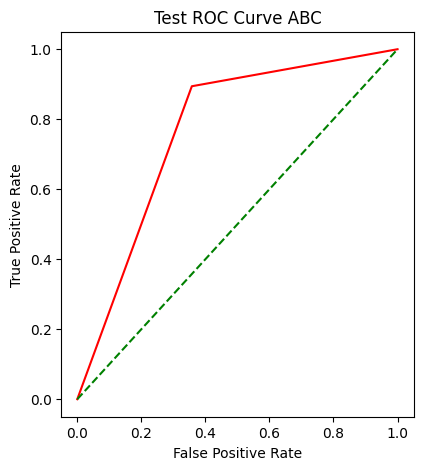

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(121)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_ABC_test)
plt.plot(fpr, tpr, color='red')
plt.plot([0, 1], [0, 1], color='green', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Test ROC Curve ABC')
plt.show()
#